# Entrenamiento y Evaluación de Modelos (Dataset Secundario)

## Importación de librerías

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
import optuna
from pathlib import Path
import joblib

## Carga del dataset

In [36]:
BASE_DIR = Path().resolve().parent
data_path = BASE_DIR / "data" / "mushrooms_clean_secondary.csv"
df = pd.read_csv(data_path)
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,p,15.26,x,g,o,f,e,unknown,w,16.95,17.09,w,t,g,d,w
1,p,16.60,x,g,o,f,e,unknown,w,17.99,18.19,w,t,g,d,u
2,p,14.07,x,g,o,f,e,unknown,w,17.80,17.74,w,t,g,d,w
3,p,14.17,f,h,e,f,e,unknown,w,15.77,15.98,w,t,p,d,w
4,p,14.64,x,h,o,f,e,unknown,w,16.53,17.20,w,t,p,d,w


## Construcción y evaluación de modelos de clasificación

In [37]:
# Se separa el dataset en variables predictoras (X) y variable objetivo (y)
X = df.drop('class', axis=1)
y = df['class']

In [38]:
# División del dataset en entrenamiento y test
# Se usa stratify para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
# Identificación de variables categóricas y numéricas
categorical_features = X.select_dtypes(include=["object", "string"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

# Pipeline de preprocesado:
# - OneHotEncoder para variables categóricas
# - Variables numéricas se mantienen sin cambios
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", "passthrough", numerical_features)
])

In [40]:
# Definición de modelos a comparar
# Se incluyen distintos algoritmos de clasificación para evaluar su rendimiento
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier()
}

In [41]:
# Creación de pipelines para cada modelo
# Se integra el preprocesado con cada algoritmo para asegurar un flujo consistente
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

In [42]:
# Entrenamiento de cada modelo incluido en los pipelines
for name, pipe in pipelines.items():
    print(f"Entrenando {name}...")
    pipe.fit(X_train, y_train)

Entrenando LogReg...
Entrenando RandomForest...
Entrenando GradientBoosting...


In [43]:
# Evaluación de modelos mediante validación cruzada
# Se utiliza F1-macro como métrica para comparar el rendimiento de forma equilibrada entre clases

cv_results = {}

for name, pipe in pipelines.items():

    print(f"Cross Validation: {name}")

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1
    )

    cv_results[name] = scores.mean()

# Conversión de resultados a DataFrame para su análisis
cv_results_df = pd.DataFrame(
    cv_results.items(),
    columns=["Modelo", "F1 CV"]
)

cv_results_df["F1 CV"] = cv_results_df["F1 CV"].round(4)

# Ordenar modelos por rendimiento
cv_results_df = cv_results_df.sort_values(
    "F1 CV",
    ascending=False
)

cv_results_df

Cross Validation: LogReg
Cross Validation: RandomForest
Cross Validation: GradientBoosting


,Modelo,F1 CV
1,RandomForest,1.0000
2,GradientBoosting,0.9360
0,LogReg,0.7767


Los resultados de la validación cruzada muestran un rendimiento muy alto del modelo RandomForest, que obtiene un F1-score perfecto de 1.00, seguido por GradientBoosting con un buen desempeño de 0.936. En cambio, la regresión logística presenta un rendimiento inferior con 0.7767, lo que indica que modelos más complejos capturan mejor la estructura del problema.

In [44]:
# Generación de predicciones en el conjunto de test para cada modelo entrenado
predictions = {}

for name, pipe in pipelines.items():
    predictions[name] = pipe.predict(X_test)

In [45]:
# Evaluación final de los modelos combinando métricas de entrenamiento, test y validación cruzada
# Se calcula también una estimación del overfitting como diferencia entre train y test

results = []

for name, pipe in pipelines.items():

    train_acc = pipe.score(X_train, y_train)
    test_acc = pipe.score(X_test, y_test)

    results.append({
        "Modelo": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "CV F1": cv_results[name],
        "Overfitting": train_acc - test_acc
    })

results_df = pd.DataFrame(results)

results_df = (
    results_df
    .round(4)
    .sort_values("Test Accuracy", ascending=False)
)

results_df

,Modelo,Train Accuracy,Test Accuracy,CV F1,Overfitting
1,RandomForest,1.0000,1.0000,1.0000,0.0000
2,GradientBoosting,0.9298,0.9292,0.9360,0.0006
0,LogReg,0.7816,0.7783,0.7767,0.0033


Los resultados muestran un rendimiento muy alto en general. RandomForest obtiene un ajuste perfecto tanto en entrenamiento como en test, sin evidencia de sobreajuste. GradientBoosting también presenta un rendimiento sólido y muy equilibrado entre train y test, con un sobreajuste prácticamente nulo. Por otro lado, la regresión logística muestra un rendimiento inferior, aunque consistente entre los distintos conjuntos, lo que indica que modelos más complejos se adaptan mejor a este problema.

## Ajuste de hiperparámetros con Optuna del modelo seleccionado (Random Forest)

In [46]:
# Función objetivo para la optimización de hiperparámetros con Optuna
# Se entrena un Random Forest con distintos parámetros y se evalúa mediante validación cruzada

def objective(trial):

    print(f"Probando trial {trial.number}...")

    # Definición del modelo con hiperparámetros sugeridos por Optuna
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 5, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        random_state=42,
        n_jobs=-1
    )

    # Pipeline que integra preprocesado y modelo
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    # Evaluación del modelo mediante validación cruzada
    # F1-macro como métrica para equilibrar el rendimiento entre clases
    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=2,
        scoring="f1_macro",
        n_jobs=-1
    ).mean()

    print(f"Trial {trial.number} terminado → F1: {score:.4f}")

    return score

In [47]:
# Inicio del proceso de optimización de hiperparámetros con Optuna

print("Iniciando optimización con Optuna...")

# Se crea el estudio indicando que se quiere maximizar la métrica F1
study = optuna.create_study(direction="maximize")

# Ejecución de múltiples pruebas (trials) para buscar la mejor combinación de hiperparámetros
study.optimize(objective, n_trials=10)

print("Optimización finalizada")

# Resultados finales de la optimización
print("Mejor score:", study.best_value)
print("Mejores parámetros:", study.best_params)

[I 2026-06-24 10:44:01,175] A new study created in memory with name: no-name-f18557cf-5578-4a1b-a170-8012ef781ce8


Iniciando optimización con Optuna...
Probando trial 0...


[I 2026-06-24 10:44:08,902] Trial 0 finished with value: 0.8385676567294515 and parameters: {'n_estimators': 266, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.8385676567294515.


Trial 0 terminado → F1: 0.8386
Probando trial 1...


[I 2026-06-24 10:44:19,416] Trial 1 finished with value: 0.9996471052856898 and parameters: {'n_estimators': 108, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.9996471052856898.


Trial 1 terminado → F1: 0.9996
Probando trial 2...


[I 2026-06-24 10:44:43,436] Trial 2 finished with value: 0.9999169657749256 and parameters: {'n_estimators': 246, 'max_depth': 23, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.9999169657749256.


Trial 2 terminado → F1: 0.9999
Probando trial 3...


[I 2026-06-24 10:45:07,294] Trial 3 finished with value: 0.9999169657749256 and parameters: {'n_estimators': 228, 'max_depth': 25, 'min_samples_split': 5, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.9999169657749256.


Trial 3 terminado → F1: 0.9999
Probando trial 4...


[I 2026-06-24 10:45:30,174] Trial 4 finished with value: 0.9999169657749256 and parameters: {'n_estimators': 239, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.9999169657749256.


Trial 4 terminado → F1: 0.9999
Probando trial 5...


[I 2026-06-24 10:45:42,072] Trial 5 finished with value: 0.9999377239599181 and parameters: {'n_estimators': 123, 'max_depth': 23, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 5 with value: 0.9999377239599181.


Trial 5 terminado → F1: 0.9999
Probando trial 6...


[I 2026-06-24 10:45:59,790] Trial 6 finished with value: 0.9995225621093405 and parameters: {'n_estimators': 223, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 5 with value: 0.9999377239599181.


Trial 6 terminado → F1: 0.9995
Probando trial 7...


[I 2026-06-24 10:46:07,687] Trial 7 finished with value: 0.9994187789675528 and parameters: {'n_estimators': 88, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 5 with value: 0.9999377239599181.


Trial 7 terminado → F1: 0.9994
Probando trial 8...


[I 2026-06-24 10:46:29,130] Trial 8 finished with value: 0.9999169650323734 and parameters: {'n_estimators': 207, 'max_depth': 28, 'min_samples_split': 7, 'min_samples_leaf': 3}. Best is trial 5 with value: 0.9999377239599181.


Trial 8 terminado → F1: 0.9999
Probando trial 9...


[I 2026-06-24 10:46:54,649] Trial 9 finished with value: 0.9998131685367138 and parameters: {'n_estimators': 275, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 5 with value: 0.9999377239599181.


Trial 9 terminado → F1: 0.9998
Optimización finalizada
Mejor score: 0.9999377239599181
Mejores parámetros: {'n_estimators': 123, 'max_depth': 23, 'min_samples_split': 9, 'min_samples_leaf': 2}


Optimización muy exitosa, con un rendimiento prácticamente perfecto. El modelo alcanza un F1 cercano a 1, lo que indica que la combinación de hiperparámetros encontrada es casi óptima para este problema.

In [48]:
# Obtención de los mejores hiperparámetros encontrados por Optuna
best_params = study.best_params

# Construcción del modelo final utilizando los parámetros óptimos
# Se integra el preprocesado en un pipeline para asegurar consistencia
best_model = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        **best_params,
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenamiento del modelo final con todo el conjunto de entrenamiento
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['e','p']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['cap-diameter','cap-shape','cap-surface',...,'ring-type','habitat', 'season']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

## Evaluación del modelo final optimizado

In [49]:
# Predicción del modelo final sobre el conjunto de test
y_pred = best_model.predict(X_test)

# Evaluación del rendimiento mediante classification report
# Incluye precision, recall y F1-score por clase
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00      5436
           p       1.00      1.00      1.00      6749

    accuracy                           1.00     12185
   macro avg       1.00      1.00      1.00     12185
weighted avg       1.00      1.00      1.00     12185



Este resultado muestra un rendimiento perfecto del modelo en el conjunto de test, con valores de precision, recall y F1-score iguales a 1.00 en ambas clases. Esto indica que el modelo es capaz de clasificar correctamente todas las muestras de setas sin cometer errores en este conjunto de evaluación.

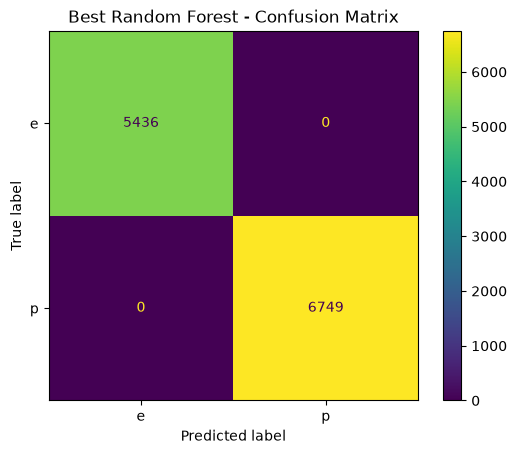

In [50]:
# Visualización de la matriz de confusión del modelo final
# Permite analizar de forma clara los aciertos y errores de clasificación por clase
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Best Random Forest - Confusion Matrix")
plt.show()

El modelo Random Forest clasifica correctamente la totalidad de los registros del conjunto de prueba, sin observarse falsos positivos ni falsos negativos. Esto se refleja en una matriz de confusión perfecta y en métricas de precisión, recall y F1-score iguales a 1.

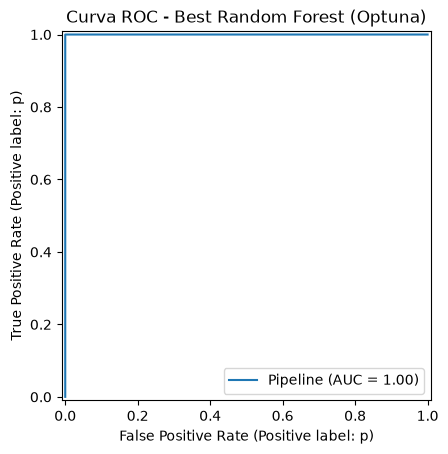

In [51]:
# Visualización de la curva ROC del modelo final
# Permite evaluar la capacidad del modelo para distinguir entre clases a distintos umbrales de decisión
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    pos_label="p"
)

plt.title("Curva ROC - Best Random Forest (Optuna)")
plt.show()

La curva ROC muestra un rendimiento prácticamente perfecto del modelo, situándose muy cerca del eje superior izquierdo. Esto indica una alta capacidad de discriminación entre clases, con una tasa de verdaderos positivos muy elevada y un número mínimo de falsos positivos. El AUC de 1.00 confirma que el modelo separa casi perfectamente las clases en el conjunto de test.

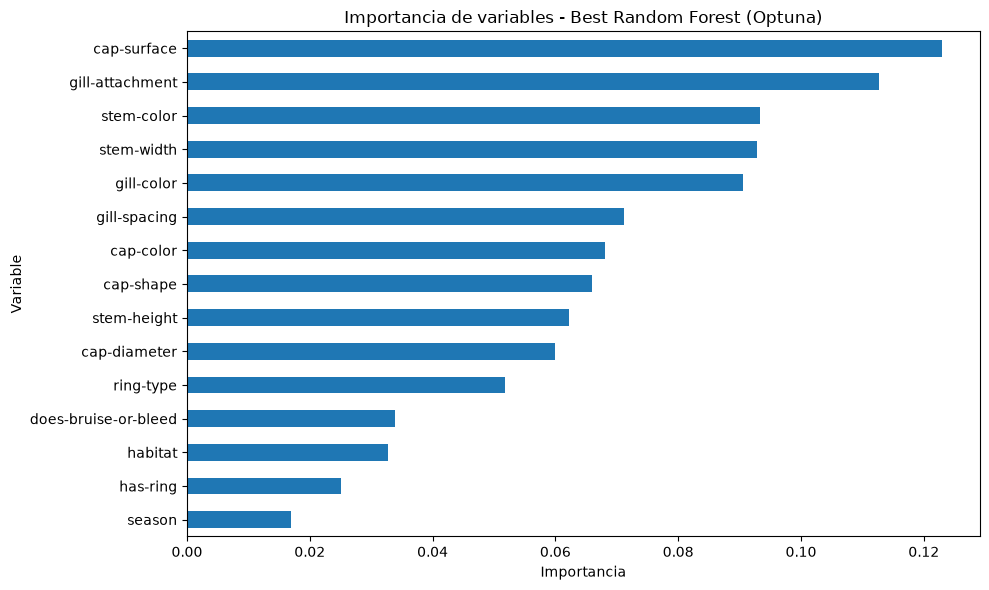

variable
cap-surface             0.123000
gill-attachment         0.112662
stem-color              0.093276
stem-width              0.092808
gill-color              0.090586
gill-spacing            0.071143
cap-color               0.068124
cap-shape               0.065907
stem-height             0.062283
cap-diameter            0.059905
ring-type               0.051744
does-bruise-or-bleed    0.033933
habitat                 0.032682
has-ring                0.025059
season                  0.016888
Name: importance, dtype: float64

In [52]:
# Extraemos el modelo entrenado
model = best_model.named_steps["model"]

# Importancias del Random Forest
importances = model.feature_importances_

# Nombres de features tras OneHotEncoding
feature_names = best_model.named_steps["prep"].get_feature_names_out()

# DataFrame
fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sacar variable original
fi_df["variable"] = (
    fi_df["feature"]
    .str.split("__").str[1]
    .str.split("_").str[0]
)

# Agrupar por variable original
fi_grouped = (
    fi_df.groupby("variable")["importance"]
    .sum()
    .sort_values(ascending=False)
)

# Gráfico
plt.figure(figsize=(10, 6))

fi_grouped.plot(kind="barh")

plt.gca().invert_yaxis()

plt.title("Importancia de variables - Best Random Forest (Optuna)")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

# Resultado en tabla
fi_grouped

El modelo basa sus predicciones principalmente en características morfológicas de la seta, especialmente la superficie del sombrero, la unión y color de las láminas y las dimensiones del tallo. En cambio, variables como la estación o la presencia de anillo aportan poca información al modelo. Esto sugiere que la clasificación depende sobre todo de rasgos estructurales visibles, mientras que otros factores tienen un impacto marginal en la predicción.

In [53]:
# Extrae el modelo entrenado (Random Forest) del pipeline para poder analizarlo o inspeccionarlo; el pipeline completo sigue siendo necesario para realizar predicciones correctas
final_model = best_model.named_steps["model"]

In [54]:
# Devuelve todos los hiperparámetros del Random Forest optimizado, útil para inspeccionar la configuración final del modelo tras la búsqueda de mejores parámetros
final_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 23,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 2,
 'min_samples_split': 9,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 123,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

Estos hiperparámetros reflejan un Random Forest bien optimizado, con alta capacidad de aprendizaje (profundidad y número de árboles elevados) y controles adecuados para evitar sobreajuste. El modelo prioriza rendimiento y estabilidad usando configuraciones estándar robustas como max_features='sqrt' y bootstrap=True.

## Guardado del modelo final

In [55]:
BASE_DIR = Path().resolve().parent

models_dir = BASE_DIR / "models"
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "best_random_forest_optuna.pkl"

joblib.dump(best_model, model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: C:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-project-classification-Grupo-1\models\best_random_forest_optuna.pkl
